# Train TabR dari POC-ABS flatten ordered v24

- sumber: `output/apex/features/poc_abs_flatten_ordered.xlsx`
- semua row frame dipakai sebagai sampel
- external test: 20 `event_clip` tiap label
- output run: `output/apex/train/t1`, `t2`, dst
- dataset train diratakan: jumlah clip per label dibuat sama
- hyperparameter final mengikuti best seed v19


## v24 pakai tabr_faithful + weighted loss\n

Internal validation tetap di-split berdasarkan `event_clip`, data train diratakan per clip antar label, dan hyperparameter final mengikuti konfigurasi terbaik dari v19 dengan seed terbaik.

In [1]:
import os
import re
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == 'preprocess-anxiety':
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f'Project root: {ROOT}')


Project root: /home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st


In [2]:
import random

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import optuna
import pandas as pd
import seaborn as sns
import torch
from joblib import dump
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
from pytorch_lightning.loggers import CSVLogger, TensorBoardLogger

from core.data_module import TabRDataModule
from core.tabr_faithful import LitTabRFaithful



In [3]:
FEATURES_PATH = ROOT / 'output/apex/features/poc_abs_flatten_ordered.xlsx'
TRAIN_ROOT = ROOT / 'output/apex/train'
N_EXTERNAL_PER_LABEL = 20
BATCH_SIZE = 128
MAX_EPOCHS = 50
RANDOM_SEED = 72
THRESHOLD = 0.5
LR = 5.34e-4
FREEZE_CONTEXT_EPOCH = 5
M_NEIGHBORS = 8
D_MODEL = 256
DROPOUT = 0.121718
EARLY_STOPPING_PATIENCE = 8

TRAIN_ROOT.mkdir(parents=True, exist_ok=True)
print(FEATURES_PATH)
print(TRAIN_ROOT)
print({
    'seed': RANDOM_SEED,
    'lr': LR,
    'freeze_context_epoch': FREEZE_CONTEXT_EPOCH,
    'm_neighbors': M_NEIGHBORS,
    'd_model': D_MODEL,
    'dropout': DROPOUT,
    'patience': EARLY_STOPPING_PATIENCE,
})


/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/features/poc_abs_flatten_ordered.xlsx
/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train
{'seed': 72, 'lr': 0.000534, 'freeze_context_epoch': 5, 'm_neighbors': 8, 'd_model': 256, 'dropout': 0.121718, 'patience': 8}


In [4]:
def get_next_train_dir(train_root: Path) -> Path:
    existing = []
    for path in train_root.iterdir():
        if path.is_dir() and re.fullmatch(r't\d+', path.name):
            existing.append(int(path.name[1:]))
    next_idx = max(existing, default=0) + 1
    out_dir = train_root / f't{next_idx}'
    out_dir.mkdir(parents=True, exist_ok=False)
    return out_dir


def plot_lightning_metrics(metrics_csv):
    import pandas as pd
    import matplotlib.pyplot as plt

    df = pd.read_csv(metrics_csv)

    if 'epoch' not in df.columns:
        raise ValueError('Kolom epoch tidak ada')

    df_epoch = (
        df.sort_values('step')
          .groupby('epoch', as_index=False)
          .last()
    )

    plt.figure()

    if 'train_loss' in df_epoch:
        plt.plot(df_epoch['epoch'], df_epoch['train_loss'], label='Train Loss')

    if 'val_loss' in df_epoch:
        plt.plot(df_epoch['epoch'], df_epoch['val_loss'], label='Val Loss')

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training vs Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()

    if 'train_acc' in df_epoch:
        plt.plot(df_epoch['epoch'], df_epoch['train_acc'], label='Train Accuracy')

    if 'val_acc' in df_epoch:
        plt.plot(df_epoch['epoch'], df_epoch['val_acc'], label='Val Accuracy')

    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training vs Validation Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()


def visualize_results(model_dir, class_names=('anxiety_rendah', 'anxiety_tinggi')):
    model_dir = str(model_dir).rstrip('/')

    cm_files = {
        'Internal': os.path.join(model_dir, 'cm_internal.png'),
        'External': os.path.join(model_dir, 'cm_external.png'),
    }

    report_files = {
        'Internal': os.path.join(model_dir, 'report_internal.csv'),
        'External': os.path.join(model_dir, 'report_external.csv'),
    }

    for name, path in cm_files.items():
        if not os.path.exists(path):
            print(f'Missing {path}')
            continue

        img = mpimg.imread(path)
        plt.figure(figsize=(5, 4))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f'TabR {name} Confusion Matrix')
        plt.show()

    for name, path in report_files.items():
        if not os.path.exists(path):
            print(f'Missing {path}')
            continue

        df = pd.read_csv(path, index_col=0)
        print(f'\n=== {name.upper()} CLASSIFICATION REPORT ===')
        print(df)


def evaluate_model(model, loader, threshold=0.5):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in loader:
            logits = model(x)
            prob = torch.softmax(logits, dim=1)[:, 1]
            preds = (prob > threshold).long()
            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, sup = precision_recall_fscore_support(y_true, y_pred, average=None)

    return {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'support': sup,
        'cm': confusion_matrix(y_true, y_pred),
        'report': classification_report(y_true, y_pred, output_dict=True),
    }


def save_confusion_matrix(cm, labels, out_path, title):
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_path)
    plt.close()


def balance_context_by_label(X, y, max_per_class=None):
    idx0 = (y == 0).nonzero(as_tuple=True)[0]
    idx1 = (y == 1).nonzero(as_tuple=True)[0]

    n = min(len(idx0), len(idx1))
    if max_per_class is not None:
        n = min(n, max_per_class)

    idx0 = idx0[torch.randperm(len(idx0))[:n]]
    idx1 = idx1[torch.randperm(len(idx1))[:n]]

    idx = torch.cat([idx0, idx1])
    idx = idx[torch.randperm(len(idx))]
    return X[idx], y[idx]


In [5]:
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.set_float32_matmul_precision('medium')

df = pd.read_excel(FEATURES_PATH)
print(df.shape)
df[['phase', 'label', 'participant', 'clip', 'event_clip', 'frame']].head()


(57656, 405)


,phase,label,participant,clip,event_clip,frame
0,before,anxiety_tinggi,aaisyah_nursalsabiil_ni_patriarti,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00054-00095,2
1,before,anxiety_tinggi,aaisyah_nursalsabiil_ni_patriarti,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00054-00095,3
2,before,anxiety_tinggi,aaisyah_nursalsabiil_ni_patriarti,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00054-00095,4
3,before,anxiety_tinggi,aaisyah_nursalsabiil_ni_patriarti,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00054-00095,5
4,before,anxiety_tinggi,aaisyah_nursalsabiil_ni_patriarti,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00054-00095,6


In [6]:
label_map = {
    'anxiety_rendah': 0,
    'anxiety_tinggi': 1,
}

df = df[df['label'].isin(label_map)].copy()
df['target'] = df['label'].map(label_map)
df['event_id'] = df['phase'].astype(str) + '||' + df['participant'].astype(str) + '||' + df['question'].astype(str) + '||' + df['clip'].astype(str) + '||' + df['event_clip'].astype(str)

event_table = df[['event_id', 'label', 'target', 'phase', 'participant', 'question', 'clip', 'event_clip']].drop_duplicates().reset_index(drop=True)
event_table.shape


(2763, 8)

In [7]:
def balanced_external_events(event_table: pd.DataFrame, n_per_label: int, seed: int = 42) -> set[str]:
    rng = random.Random(seed)
    selected_ids: list[str] = []

    for label_name in ['anxiety_rendah', 'anxiety_tinggi']:
        label_df = event_table[event_table['label'] == label_name].copy()
        if label_df.empty:
            continue

        picked_rows = []
        used_ids = set()

        participant_groups = []
        for participant, part_df in label_df.groupby('participant', sort=True):
            part_df = part_df.sort_values(['phase', 'question', 'clip', 'event_clip'], kind='stable')
            phase_groups = []
            for phase, phase_df in part_df.groupby('phase', sort=True):
                phase_groups.append(phase_df.to_dict('records'))
            participant_groups.append((participant, phase_groups))

        while len(picked_rows) < n_per_label:
            progress = False
            for _participant, phase_groups in participant_groups:
                for records in phase_groups:
                    while records and records[0]['event_id'] in used_ids:
                        records.pop(0)
                    if not records:
                        continue
                    row = records.pop(0)
                    picked_rows.append(row)
                    used_ids.add(row['event_id'])
                    progress = True
                    if len(picked_rows) >= n_per_label:
                        break
                if len(picked_rows) >= n_per_label:
                    break
            if not progress:
                break

        if len(picked_rows) < n_per_label:
            remaining = label_df[~label_df['event_id'].isin(used_ids)].sort_values(['participant', 'phase', 'question', 'clip', 'event_clip'], kind='stable')
            for row in remaining.to_dict('records'):
                picked_rows.append(row)
                used_ids.add(row['event_id'])
                if len(picked_rows) >= n_per_label:
                    break

        selected_ids.extend([row['event_id'] for row in picked_rows[:n_per_label]])

    return set(selected_ids)


external_event_ids = balanced_external_events(event_table, N_EXTERNAL_PER_LABEL, seed=RANDOM_SEED)
df_external = df[df['event_id'].isin(external_event_ids)].copy()
df_train_all = df[~df['event_id'].isin(external_event_ids)].copy()

print('External events:', len(external_event_ids))
print('External rows:', df_external.shape)
print('Train rows:', df_train_all.shape)
print(event_table[event_table['event_id'].isin(external_event_ids)]['label'].value_counts().to_dict())
print(event_table[event_table['event_id'].isin(external_event_ids)].groupby('label')['participant'].nunique())
print(pd.crosstab(event_table[event_table['event_id'].isin(external_event_ids)]['phase'], event_table[event_table['event_id'].isin(external_event_ids)]['label']))


External events: 40
External rows: (906, 407)
Train rows: (56750, 407)
{'anxiety_tinggi': 20, 'anxiety_rendah': 20}
label
anxiety_rendah    15
anxiety_tinggi    14
Name: participant, dtype: int64
label   anxiety_rendah  anxiety_tinggi
phase                                 
after               14               7
before               6              13


In [8]:
def balance_train_clips_by_label(df_train: pd.DataFrame, seed: int = 42):
    rng = random.Random(seed)
    event_table_train = (
        df_train[['event_id', 'label', 'target', 'phase', 'participant', 'question', 'clip', 'event_clip']]
        .drop_duplicates()
        .reset_index(drop=True)
    )

    grouped = {}
    for label_name, label_df in event_table_train.groupby('label', sort=True):
        clip_table = (
            label_df[['participant', 'question', 'clip', 'label']]
            .drop_duplicates()
            .sort_values(['participant', 'question', 'clip'], kind='stable')
            .reset_index(drop=True)
        )
        grouped[label_name] = clip_table

    min_clip_count = min(len(clip_table) for clip_table in grouped.values())
    selected_clip_keys = []
    clip_balance_rows = []

    for label_name, clip_table in grouped.items():
        clip_records = clip_table.to_dict('records')
        rng.shuffle(clip_records)
        chosen = clip_records[:min_clip_count]
        clip_balance_rows.extend(chosen)
        selected_clip_keys.extend([
            (row['participant'], row['question'], row['clip'], row['label'])
            for row in chosen
        ])

    selected_clip_keys = set(selected_clip_keys)
    df_balanced = df_train[
        df_train.apply(
            lambda row: (row['participant'], row['question'], row['clip'], row['label']) in selected_clip_keys,
            axis=1,
        )
    ].copy()

    clip_balance_df = pd.DataFrame(clip_balance_rows)
    return df_balanced, clip_balance_df


df_train_all_balanced, train_clip_balance = balance_train_clips_by_label(df_train_all, seed=RANDOM_SEED)
train_event_table_balanced = (
    df_train_all_balanced[['event_id', 'label', 'target']]
    .drop_duplicates()
    .reset_index(drop=True)
)

print('Train rows before balance:', df_train_all.shape)
print('Train rows after balance:', df_train_all_balanced.shape)
print('Balanced clips per label:')
print(train_clip_balance['label'].value_counts())
print('Balanced events per label:')
print(train_event_table_balanced['label'].value_counts())



Train rows before balance: (56750, 407)
Train rows after balance: (48892, 407)
Balanced clips per label:
label
anxiety_rendah    160
anxiety_tinggi    160
Name: count, dtype: int64
Balanced events per label:
label
anxiety_tinggi    1248
anxiety_rendah    1112
Name: count, dtype: int64


In [9]:
meta_cols = [
    'phase', 'condition', 'label', 'participant', 'participant_raw', 'question', 'question_no',
    'sample', 'clip', 'event_clip', 'event_no', 'clip_path', 'frame', 'target', 'event_id',
]
feature_cols = [c for c in df.columns if c not in meta_cols]
print('n_features =', len(feature_cols))
feature_cols[:10]


n_features = 392


['mulut_x1',
 'mulut_y1',
 'mulut_t1',
 'mulut_m1',
 'mulut_x2',
 'mulut_y2',
 'mulut_t2',
 'mulut_m2',
 'mulut_x3',
 'mulut_y3']

In [10]:
train_events = train_event_table_balanced.copy()
train_event_ids, val_event_ids = train_test_split(
    train_events['event_id'],
    test_size=0.3,
    stratify=train_events['target'],
    random_state=RANDOM_SEED,
)

train_event_ids = set(train_event_ids.tolist())
val_event_ids = set(val_event_ids.tolist())

df_tr = df_train_all_balanced[df_train_all_balanced['event_id'].isin(train_event_ids)].copy()
df_val = df_train_all_balanced[df_train_all_balanced['event_id'].isin(val_event_ids)].copy()

imputer = SimpleImputer(strategy='mean')
scaler = StandardScaler()

X_train_np = scaler.fit_transform(imputer.fit_transform(df_tr[feature_cols]))
X_val_np = scaler.transform(imputer.transform(df_val[feature_cols]))
X_ext_np = scaler.transform(imputer.transform(df_external[feature_cols]))

X_train = torch.tensor(X_train_np, dtype=torch.float32)
y_train = torch.tensor(df_tr['target'].values, dtype=torch.long)
X_val = torch.tensor(X_val_np, dtype=torch.float32)
y_val = torch.tensor(df_val['target'].values, dtype=torch.long)
X_ext = torch.tensor(X_ext_np, dtype=torch.float32)
y_ext = torch.tensor(df_external['target'].values, dtype=torch.long)

ctx_train_X, ctx_train_y = balance_context_by_label(X_train, y_train)
ctx_val_X, ctx_val_y = X_val, y_val

print('train events:', len(train_event_ids))
print('val events:', len(val_event_ids))
print(X_train.shape, X_val.shape, X_ext.shape)

class_counts = torch.bincount(y_train, minlength=2).float()
class_weights = (class_counts.sum() / (len(class_counts) * class_counts)).to(torch.float32)
print('class_counts =', class_counts.tolist())
print('class_weights =', class_weights.tolist())


train events: 1652
val events: 708
torch.Size([34360, 392]) torch.Size([14532, 392]) torch.Size([906, 392])
class_counts = [14757.0, 19603.0]
class_weights = [1.1641932725906372, 0.8763964772224426]


In [11]:
def train_tabr_from_dataframe(out_dir: Path):
    dm = TabRDataModule(
        X_train, y_train,
        X_val, y_val,
        ctx_train_X, ctx_train_y,
        ctx_val_X, ctx_val_y,
        batch_size=BATCH_SIZE,
    )

    model = LitTabRFaithful(
        in_dim=len(feature_cols),
        num_classes=2,
        d_main=D_MODEL,
        n_blocks=3,
        n_neighbors=M_NEIGHBORS,
        freeze_context_epoch=FREEZE_CONTEXT_EPOCH,
        lr=LR,
        dropout=DROPOUT,
        weight_decay=1e-5,
        class_weights=class_weights,
    )

    checkpoint_cb = ModelCheckpoint(
        dirpath=str(out_dir),
        filename='best',
        monitor='val_loss',
        mode='min',
        save_top_k=1,
    )

    loggers = [
        CSVLogger(save_dir=str(out_dir), name='tabr_logs'),
        TensorBoardLogger(save_dir=str(out_dir), name='tb_logs'),
    ]

    trainer = pl.Trainer(
        max_epochs=MAX_EPOCHS,
        accelerator='gpu' if torch.cuda.is_available() else 'cpu',
        devices=1,
        logger=loggers,
        log_every_n_steps=1,
        default_root_dir=str(out_dir),
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=EARLY_STOPPING_PATIENCE, mode='min'),
            checkpoint_cb,
        ],
    )

    trainer.fit(model, datamodule=dm)

    best_ckpt = checkpoint_cb.best_model_path or str(out_dir / 'best.ckpt')
    if checkpoint_cb.best_model_path:
        model = LitTabRFaithful.load_from_checkpoint(checkpoint_cb.best_model_path, weights_only=False).to(model.get_device())
    trainer.save_checkpoint(str(out_dir / 'last.ckpt'))

    model.set_preprocessor(imputer=imputer, scaler=scaler, feature_cols=feature_cols)
    model.set_default_context(ctx_train_X, ctx_train_y)

    dump(imputer, out_dir / 'imputer.joblib')
    dump(scaler, out_dir / 'scaler.joblib')
    dump(feature_cols, out_dir / 'feature_cols.joblib')
    dump((ctx_train_X.cpu(), ctx_train_y.cpu()), out_dir / 'context.joblib')
    df_tr.to_csv(out_dir / 'train_split.csv', index=False)
    df_val.to_csv(out_dir / 'val_split.csv', index=False)
    df_external.to_csv(out_dir / 'external_test.csv', index=False)
    pd.DataFrame([{
        'seed': RANDOM_SEED,
        'lr': LR,
        'freeze_context_epoch': FREEZE_CONTEXT_EPOCH,
        'm_neighbors': M_NEIGHBORS,
        'd_model': D_MODEL,
        'dropout': DROPOUT,
        'patience': EARLY_STOPPING_PATIENCE,
        'best_checkpoint': best_ckpt,
    }]).to_csv(out_dir / 'run_config.csv', index=False)

    print('INTERNAL')
    model.eval()
    model.set_context(ctx_train_X, ctx_train_y)
    val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False, num_workers=8)
    res_int = evaluate_model(model, val_loader, threshold=THRESHOLD)

    print('EXTERNAL')
    ext_loader = DataLoader(TensorDataset(X_ext, y_ext), batch_size=BATCH_SIZE, shuffle=False, num_workers=8)
    res_ext = evaluate_model(model, ext_loader, threshold=THRESHOLD)

    pd.DataFrame(res_int['report']).transpose().to_csv(out_dir / 'report_internal.csv')
    pd.DataFrame(res_ext['report']).transpose().to_csv(out_dir / 'report_external.csv')

    save_confusion_matrix(res_int['cm'], ['anxiety_rendah', 'anxiety_tinggi'], out_dir / 'cm_internal.png', 'TabR Internal Confusion Matrix')
    save_confusion_matrix(res_ext['cm'], ['anxiety_rendah', 'anxiety_tinggi'], out_dir / 'cm_external.png', 'TabR External Confusion Matrix')

    pd.DataFrame({
        'split': ['internal', 'external'],
        'accuracy': [res_int['accuracy'], res_ext['accuracy']],
    }).to_csv(out_dir / 'summary_metrics.csv', index=False)

    return model, {'internal': res_int, 'external': res_ext}



In [12]:
OUT_DIR = get_next_train_dir(TRAIN_ROOT)
print(OUT_DIR)
model, results = train_tabr_from_dataframe(OUT_DIR)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train/t90


/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train/t90 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | encoder   | TabREncoder      | 100 K  | train | 0    
1 | WK        | Linear           | 65.5 K | train | 0    
2 | WY        | Embedding        | 512    | train | 0    
3 | T         | ValueCorrection  | 131 K  | train | 0    
4 | predictor | Sequential       | 132 K  | train | 0    
5 | head      | Linear           | 514    | train | 0    
6 | loss_fn   | CrossEntropyLoss | 0      | train | 0    
---------------------------------------------------------------
430 K     Trainable params
0         Non-trainable params
430 K     Total params
1.721     Total esti

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Validation context rebuilt from train context


...

Validation context rebuilt from train context


Validation: |          | 0/? [00:00<?, ?it/s]

Validation context rebuilt from train context


`weights_only` was not set, defaulting to `False`.


INTERNAL
EXTERNAL


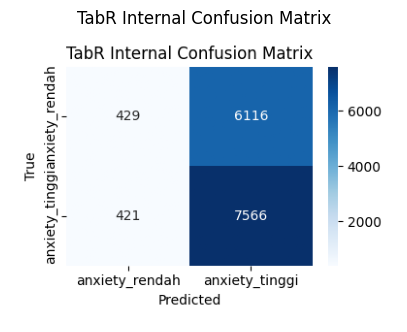

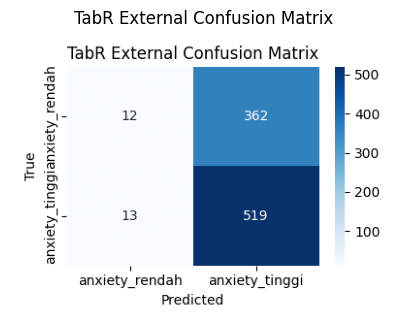


=== INTERNAL CLASSIFICATION REPORT ===
              precision    recall  f1-score       support
0              0.504706  0.065546  0.116024   6545.000000
1              0.552989  0.947289  0.698325   7987.000000
accuracy       0.550165  0.550165  0.550165      0.550165
macro avg      0.528848  0.506418  0.407175  14532.000000
weighted avg   0.531243  0.550165  0.436065  14532.000000

=== EXTERNAL CLASSIFICATION REPORT ===
              precision    recall  f1-score     support
0              0.480000  0.032086  0.060150  374.000000
1              0.589103  0.975564  0.734607  532.000000
accuracy       0.586093  0.586093  0.586093    0.586093
macro avg      0.534552  0.503825  0.397379  906.000000
weighted avg   0.544065  0.586093  0.456189  906.000000


In [13]:
visualize_results(OUT_DIR)


/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train/t90/tabr_logs/version_0/metrics.csv


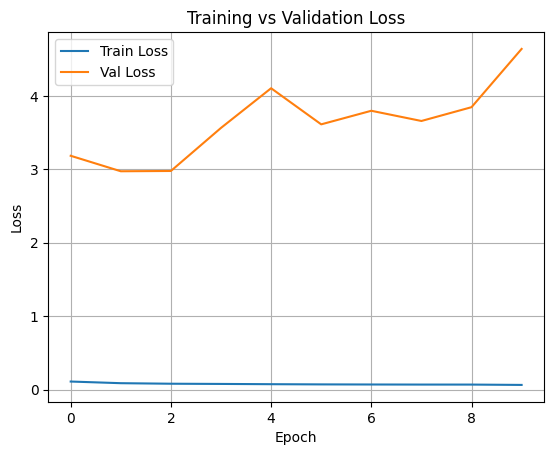

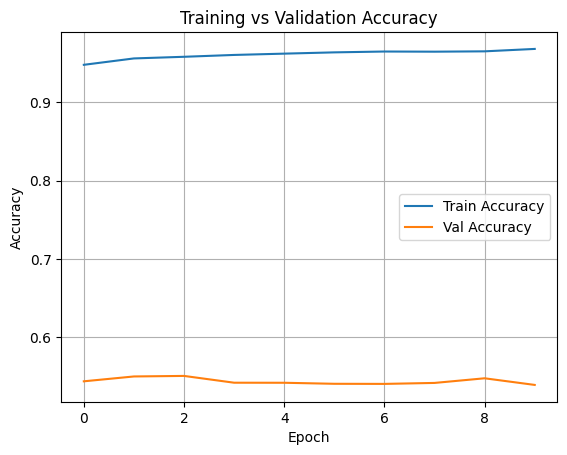

In [14]:
metrics_csv = sorted((OUT_DIR / 'tabr_logs').glob('version_*/metrics.csv'))[-1]
print(metrics_csv)
plot_lightning_metrics(metrics_csv)


In [15]:
print('SUMMARY METRICS')
print(pd.DataFrame({
    'split': ['internal', 'external'],
    'accuracy': [results['internal']['accuracy'], results['external']['accuracy']],
}))
print('\nINTERNAL REPORT')
print(pd.DataFrame(results['internal']['report']).transpose())
print('\nEXTERNAL REPORT')
print(pd.DataFrame(results['external']['report']).transpose())


SUMMARY METRICS
      split  accuracy
0  internal  0.550165
1  external  0.586093

INTERNAL REPORT
              precision    recall  f1-score       support
0              0.504706  0.065546  0.116024   6545.000000
1              0.552989  0.947289  0.698325   7987.000000
accuracy       0.550165  0.550165  0.550165      0.550165
macro avg      0.528848  0.506418  0.407175  14532.000000
weighted avg   0.531243  0.550165  0.436065  14532.000000

EXTERNAL REPORT
              precision    recall  f1-score     support
0              0.480000  0.032086  0.060150  374.000000
1              0.589103  0.975564  0.734607  532.000000
accuracy       0.586093  0.586093  0.586093    0.586093
macro avg      0.534552  0.503825  0.397379  906.000000
weighted avg   0.544065  0.586093  0.456189  906.000000
